In [1]:
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Telco-Customer-Churn.csv')
print("Filas y columnas:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())
df.head()

Filas y columnas: (7043, 21)

Columnas:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

print("\nValores nulos por columna:")
print(df.isna().sum())

print("\nIDs de cliente duplicados:")
print(df["customerID"].duplicated().sum())

print("\nValores de TotalCharges que no se pueden convertir a número:")
print(pd.to_numeric(df["TotalCharges"], errors="coerce").isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# Convertir temporalmente los cargos totales a números
total_charges_numeric = pd.to_numeric(
    df["TotalCharges"], errors="coerce"
)

# Seleccionar las filas que no pudieron convertirse
filas_revisar = total_charges_numeric.isna()

display(
    df.loc[
        filas_revisar,
        ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
    ]
)

# Mostrar el contenido original, incluidos espacios entre comillas
print("Valores originales:")
print(df.loc[filas_revisar, "TotalCharges"].apply(repr).unique())

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


Valores originales:
["' '"]


In [ ]:
# Crear una copia para la limpieza
df_clean = df.copy()

# Convertir TotalCharges a número; los espacios pasan a NaN
df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"], errors="coerce"
)

# Comprobar el resultado
print("Filas y columnas:", df_clean.shape)
print("Tipo de TotalCharges:", df_clean["TotalCharges"].dtype)
print("Cargos totales faltantes:", df_clean["TotalCharges"].isna().sum())

Filas y columnas: (7043, 21)
Tipo de TotalCharges: float64
Cargos totales faltantes: 11


In [ ]:
# Revisar los valores distintos de cada columna de texto
for columna in df_clean.select_dtypes(include="object").columns:
    if columna != "customerID":
        print(f"{columna}:")
        print(df_clean[columna].unique())
        print()

gender:
['Female' 'Male']

Partner:
['Yes' 'No']

Dependents:
['No' 'Yes']

PhoneService:
['No' 'Yes']

MultipleLines:
['No phone service' 'No' 'Yes']

InternetService:
['DSL' 'Fiber optic' 'No']

OnlineSecurity:
['No' 'Yes' 'No internet service']

OnlineBackup:
['Yes' 'No' 'No internet service']

DeviceProtection:
['No' 'Yes' 'No internet service']

TechSupport:
['No' 'Yes' 'No internet service']

StreamingTV:
['No' 'Yes' 'No internet service']

StreamingMovies:
['No' 'Yes' 'No internet service']

Contract:
['Month-to-month' 'One year' 'Two year']

PaperlessBilling:
['Yes' 'No']

PaymentMethod:
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Churn:
['No' 'Yes']



In [ ]:
# Contar los clientes y las cancelaciones
total_clientes = len(df_clean)
clientes_cancelados = (df_clean["Churn"] == "Yes").sum()
clientes_permanecen = (df_clean["Churn"] == "No").sum()

# Calcular el porcentaje de cancelación
tasa_cancelacion = clientes_cancelados / total_clientes * 100

print("Total de clientes:", total_clientes)
print("Clientes que cancelaron:", clientes_cancelados)
print("Clientes que permanecen:", clientes_permanecen)
print(f"Tasa de cancelación: {tasa_cancelacion:.2f}%")

Total de clientes: 7043
Clientes que cancelaron: 1869
Clientes que permanecen: 5174
Tasa de cancelación: 26.54%


In [ ]:
# Representar la cancelación con 1 y la permanencia con 0
df_clean["ChurnFlag"] = df_clean["Churn"].map({"Yes": 1, "No": 0})

# Agrupar los clientes por tipo de contrato
churn_por_contrato = df_clean.groupby("Contract").agg(
    total_clientes=("customerID", "count"),
    cancelaciones=("ChurnFlag", "sum")
)

# Calcular la tasa dentro de cada tipo de contrato
churn_por_contrato["tasa_cancelacion_pct"] = (
    churn_por_contrato["cancelaciones"]
    / churn_por_contrato["total_clientes"]
    * 100
).round(2)

display(
    churn_por_contrato.sort_values(
        "tasa_cancelacion_pct", ascending=False
    )
)

,total_clientes,cancelaciones,tasa_cancelacion_pct
Contract,,,
Month-to-month,3875,1655,42.71
One year,1473,166,11.27
Two year,1695,48,2.83


In [ ]:
churn_por_internet = df_clean.groupby("InternetService").agg(
    total_clientes=("customerID", "count"),
    cancelaciones=("ChurnFlag", "sum")
)

churn_por_internet["tasa_cancelacion_pct"] = (
    churn_por_internet["cancelaciones"]
    / churn_por_internet["total_clientes"]
    * 100
).round(2)

display(
    churn_por_internet.sort_values(
        "tasa_cancelacion_pct", ascending=False
    )
)

,total_clientes,cancelaciones,tasa_cancelacion_pct
InternetService,,,
Fiber optic,3096,1297,41.89
DSL,2421,459,18.96
No,1526,113,7.40


In [ ]:
# Agrupar por contrato y servicio de internet a la vez
churn_contrato_internet = df_clean.groupby(
    ["Contract", "InternetService"]
).agg(
    total_clientes=("customerID", "count"),
    cancelaciones=("ChurnFlag", "sum")
)

churn_contrato_internet["tasa_cancelacion_pct"] = (
    churn_contrato_internet["cancelaciones"]
    / churn_contrato_internet["total_clientes"]
    * 100
).round(2)

display(churn_contrato_internet)

total_clientes  cancelaciones  \
Contract       InternetService                                  
Month-to-month DSL                        1223            394   
               Fiber optic                2128           1162   
               No                          524             99   
One year       DSL                         570             53   
               Fiber optic                 539            104   
               No                          364              9   
Two year       DSL                         628             12   
               Fiber optic                 429             31   
               No                          638              5   

                                tasa_cancelacion_pct  
Contract       InternetService                        
Month-to-month DSL                             32.22  
               Fiber optic                     54.61  
               No                              18.89  
One year       DSL                              9.30  
               Fiber optic                     19.29  
               No                               2.47  
Two year       DSL                              1.91  
               Fiber optic                      7.23  
               No                               0.78

In [ ]:
# Crear grupos de antigüedad
df_clean["TenureGroup"] = pd.cut(
    df_clean["tenure"],
    bins=[-1, 0, 12, 24, 48, float("inf")],
    labels=["0 meses", "1–12 meses", "13–24 meses",
            "25–48 meses", "49+ meses"]
)

# Calcular clientes y cancelaciones por grupo
churn_por_antiguedad = df_clean.groupby(
    "TenureGroup", observed=True
).agg(
    total_clientes=("customerID", "count"),
    cancelaciones=("ChurnFlag", "sum")
)

churn_por_antiguedad["tasa_cancelacion_pct"] = (
    churn_por_antiguedad["cancelaciones"]
    / churn_por_antiguedad["total_clientes"]
    * 100
).round(2)

display(churn_por_antiguedad)

,total_clientes,cancelaciones,tasa_cancelacion_pct
TenureGroup,,,
0 meses,11,0,0.00
1–12 meses,2175,1037,47.68
13–24 meses,1024,294,28.71
25–48 meses,1594,325,20.39
49+ meses,2239,213,9.51


In [ ]:
# Seleccionar clientes de fibra con contrato mensual
segmento = df_clean[
    (df_clean["InternetService"] == "Fiber optic")
    & (df_clean["Contract"] == "Month-to-month")
]

# Comparar sus grupos de antigüedad
churn_segmento = segmento.groupby(
    "TenureGroup", observed=True
).agg(
    total_clientes=("customerID", "count"),
    cancelaciones=("ChurnFlag", "sum")
)

churn_segmento["tasa_cancelacion_pct"] = (
    churn_segmento["cancelaciones"]
    / churn_segmento["total_clientes"]
    * 100
).round(2)

display(churn_segmento)

,total_clientes,cancelaciones,tasa_cancelacion_pct
TenureGroup,,,
1–12 meses,916,643,70.20
13–24 meses,425,215,50.59
25–48 meses,521,226,43.38
49+ meses,266,78,29.32


In [ ]:
# Clientes de fibra mensual con entre 1 y 12 meses
segmento_nuevo = segmento[
    segmento["tenure"].between(1, 12)
]

# Comparar según tengan soporte técnico contratado
churn_por_soporte = segmento_nuevo.groupby("TechSupport").agg(
    total_clientes=("customerID", "count"),
    cancelaciones=("ChurnFlag", "sum")
)

churn_por_soporte["tasa_cancelacion_pct"] = (
    churn_por_soporte["cancelaciones"]
    / churn_por_soporte["total_clientes"]
    * 100
).round(2)

display(churn_por_soporte)

,total_clientes,cancelaciones,tasa_cancelacion_pct
TechSupport,,,
No,833,592,71.07
Yes,83,51,61.45


In [ ]:
resumen_cargos = segmento_nuevo.groupby("Churn").agg(
    clientes=("customerID", "count"),
    cargo_promedio=("MonthlyCharges", "mean"),
    cargo_mediano=("MonthlyCharges", "median"),
    cargo_minimo=("MonthlyCharges", "min"),
    cargo_maximo=("MonthlyCharges", "max")
).round(2)

display(resumen_cargos)

,clientes,cargo_promedio,cargo_mediano,cargo_minimo,cargo_maximo
Churn,,,,,
No,273,80.6,79.15,68.95,111.40
Yes,643,82.7,80.50,67.75,112.95


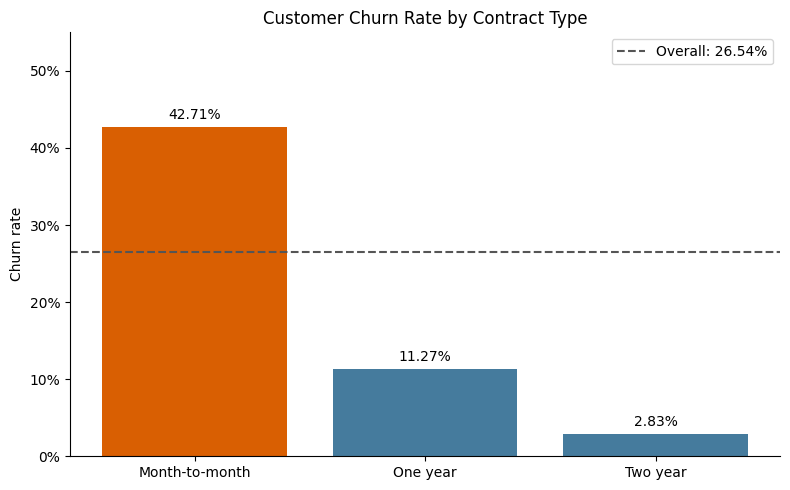

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

datos = churn_por_contrato.reindex(
    ["Month-to-month", "One year", "Two year"]
)

fig, ax = plt.subplots(figsize=(8, 5))

barras = ax.bar(
    ["Month-to-month", "One year", "Two year"],
    datos["tasa_cancelacion_pct"],
    color=["#D95F02", "#457B9D", "#457B9D"]
)

ax.bar_label(
    barras,
    labels=[f"{valor:.2f}%" for valor in datos["tasa_cancelacion_pct"]],
    padding=4
)

ax.axhline(
    tasa_cancelacion,
    color="#555555",
    linestyle="--",
    label=f"Overall: {tasa_cancelacion:.2f}%"
)

ax.set_title("Customer Churn Rate by Contract Type")
ax.set_ylabel("Churn rate")
ax.set_ylim(0, 55)
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.spines[["top", "right"]].set_visible(False)
ax.legend()

plt.tight_layout()
plt.show()

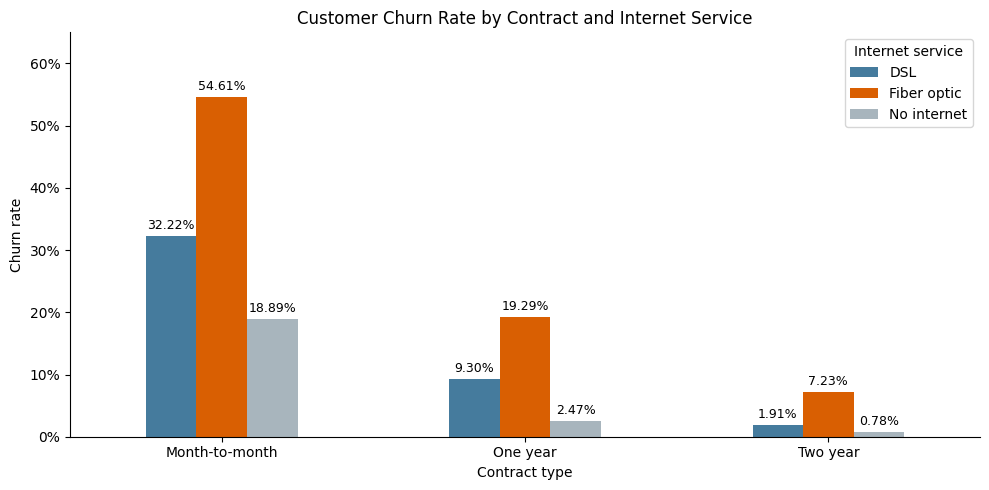

In [ ]:
# Colocar los servicios de internet en columnas
tasas = churn_contrato_internet[
    "tasa_cancelacion_pct"
].unstack("InternetService")

tasas = tasas.reindex(
    index=["Month-to-month", "One year", "Two year"],
    columns=["DSL", "Fiber optic", "No"]
).rename(columns={"No": "No internet"})

# Crear barras agrupadas
ax = tasas.plot(
    kind="bar",
    figsize=(10, 5),
    color=["#457B9D", "#D95F02", "#A8B5BD"],
    rot=0
)

for barras in ax.containers:
    ax.bar_label(
        barras,
        labels=[f"{barra.get_height():.2f}%" for barra in barras],
        padding=3,
        fontsize=9
    )

ax.set_title("Customer Churn Rate by Contract and Internet Service")
ax.set_xlabel("Contract type")
ax.set_ylabel("Churn rate")
ax.set_ylim(0, 65)
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="Internet service")

plt.tight_layout()
plt.show()

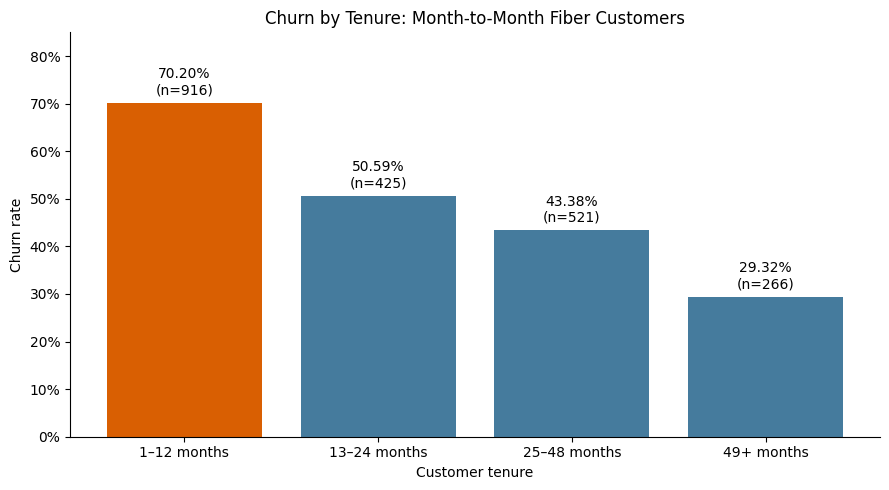

In [ ]:
datos = churn_segmento.copy()

fig, ax = plt.subplots(figsize=(9, 5))

barras = ax.bar(
    ["1–12 months", "13–24 months", "25–48 months", "49+ months"],
    datos["tasa_cancelacion_pct"],
    color=["#D95F02", "#457B9D", "#457B9D", "#457B9D"]
)

etiquetas = [
    f"{tasa:.2f}%\n(n={int(clientes):,})"
    for tasa, clientes in zip(
        datos["tasa_cancelacion_pct"],
        datos["total_clientes"]
    )
]

ax.bar_label(barras, labels=etiquetas, padding=4)

ax.set_title("Churn by Tenure: Month-to-Month Fiber Customers")
ax.set_xlabel("Customer tenure")
ax.set_ylabel("Churn rate")
ax.set_ylim(0, 85)
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
ruta_salida = "/content/drive/MyDrive/telco_customer_churn_clean.csv"

df_clean.to_csv(
    ruta_salida,
    index=False,
    encoding="utf-8",
    na_rep=""
)

print("Archivo guardado:", ruta_salida)
print("Filas y columnas:", df_clean.shape)
print("Cargos totales faltantes:", df_clean["TotalCharges"].isna().sum())

Archivo guardado: /content/drive/MyDrive/telco_customer_churn_clean.csv
Filas y columnas: (7043, 23)
Cargos totales faltantes: 11


## Key Findings

- Overall churn was **26.54%**, representing **1,869 of 7,043 customers**.
- Month-to-month customers had a churn rate of **42.71%**, compared with **11.27%** for one-year contracts and **2.83%** for two-year contracts.
- Fiber optic customers had higher churn than DSL customers within all three contract types.
- Customers with fiber optic service, month-to-month contracts, and 1–12 months of tenure had a churn rate of **70.20%**: **643 out of 916 customers**. This segment represented approximately **13.0% of customers** and **34.4% of all churned customers**.
- Within this segment, churn was **71.07% without technical support** and **61.45% with technical support**. The support group was much smaller: 83 customers versus 833.
- Average monthly charges within this segment were **82.70 for churned customers** and **80.60 for customers who stayed**. This comparison alone does not establish price as a cause of churn.

## Recommendations

- Prioritize research into the experience of customers with fiber optic service, monthly contracts, and short tenure.
- Collect cancellation reasons, support interactions, and service performance data to investigate potential causes.
- Test onboarding assistance or support offers through a controlled pilot. Measure changes in churn and the cost of retaining customers before expanding the program.

## Data Preparation and Limitations

- All **7,043 customer records** were retained, with no duplicate customer IDs detected.
- Eleven blank `TotalCharges` values belonged to customers with zero months of tenure. These values were converted to missing numeric values rather than assumed to be zero.
- `ChurnFlag` and `TenureGroup` were created for analysis.
- This is an IBM sample dataset representing a fictional telecommunications company.
- The findings describe associations, not causal effects or individual predictions. Churn percentages by tenure are not cumulative probabilities of leaving during those months.